# Downloading JWST and Euclid data

In [1]:
import os
from io import BytesIO
from astropy.io import fits
import matplotlib.pyplot as plt
import dropbox
import time
import numpy as np
import pandas as pd
from astropy.wcs import WCS
from astropy.wcs.utils import proj_plane_pixel_scales
from astropy.coordinates import SkyCoord
from astropy.nddata import Cutout2D
import warnings
from astropy.wcs import FITSFixedWarning
from scipy import ndimage
from sklearn.preprocessing import MinMaxScaler

In [3]:
warnings.simplefilter('ignore', FITSFixedWarning)

In [5]:
# Links to shared folders
dbx_url = 'https://www.dropbox.com/scl/fo/37ooho4m924wb3d2m1gt8/ABJjd8gNUl0h_rmUP41S3cI?rlkey=nqy0t7p9sgxa3a853bf1ris9l&st=clxv8yui&dl=0'
# jwst_url = 'https://www.dropbox.com/scl/fo/eo3ktfmhniyqm7l32egp4/ANfH2VisN0vIphVxNIpO_ag/JWST?rlkey=enfshikpl0r0wd8o2nz66i0km&subfolder_nav_tracking=1&st=w3u4yz80&dl=0'
# nisp_url = 'https://www.dropbox.com/scl/fo/eo3ktfmhniyqm7l32egp4/AEiIbqfbMKqh6FRA2YouLHQ/NISP-J?rlkey=enfshikpl0r0wd8o2nz66i0km&subfolder_nav_tracking=1&st=hx3ru322&dl=0'

# Catalog files
farmer_cat_path = '../catalog/COSMOS2020_FARMER_R1_v2.2_p3.fits'
classic_cat_path = '../catalog/COSMOS2020_CLASSIC_R1_v2.2_p3.fits'
candels_cat_path = '../catalog/gds.fits'

# Data files
matched_cat_file = '../catalog/matched_cat_COSMOS.csv'
np_jwst_file = '../data/jwst_cosmos_66px.npy'
np_nisp_file = '../data/nisp_cosmos_40px.npy'

In [7]:
def get_shared_folder_metadata(url, dbx, path=""):
    """Get metadata of the shared folder."""
    shared_link = dropbox.files.SharedLink(url=url)
    try:
        folder_metadata = dbx.files_list_folder(path=f'{path}', shared_link=shared_link)
        return folder_metadata.entries
    except dropbox.exceptions.ApiError as e:
        print(f"Error accessing shared folder: {e}")
        return []

def get_fits_file(url, file_name, dbx, hdu_idx=0):
    tries=5
    while tries >= 0:
        tries -= 1
        try:
            meta, res = dbx.sharing_get_shared_link_file(url, path=file_name)
            break
        except Exception as e:
            print(f"Connection error: {e}")
            time.sleep(10)
            continue

    try: res
    except: raise RuntimeError(f"Could not access file {file_name} at URL {url}.")

    fits_file = BytesIO(res.content)
    hdul = fits.open(fits_file)

    # Access image data
    image_data = hdul[hdu_idx].data
    image_header = hdul[hdu_idx].header
    hdul.close()
    return image_header, image_data

def cut_catalog(cat_file=classic_cat_path, cuts=None):
    # Open cat file
    with fits.open(cat_file) as hdul:
        cat_data = hdul[1].data  # Adjust the HDU index if your data is not in the first extension
    
    # Do cuts on catalog data
    if cuts is None:
        cuts = (cat_data.lp_type==0) & \
                (cat_data.ACS_F814W_MAG < 25) & \
                (cat_data.ez_z_phot > 0.01) & (cat_data.ez_z_phot < 3.0) & \
                (cat_data.FLUX_RADIUS < 104) # TODO: make this a function with J&H bands?
    
    cat_clipped = cat_data[cuts]
    
    my_cat = pd.DataFrame({'id_classic': cat_clipped['ID'].astype(int),
                           'ra': cat_clipped['ALPHA_J2000'].astype(float),
                           'dec': cat_clipped['DELTA_J2000'].astype(float),
                           'jwst_image': "",
                           'nisp_image': "",
                          })
    
    return my_cat

def cut_catalog2(cat_file=candels_cat_path, cuts=None):

    cat_data = Table.read(cat_file).to_pandas()
    
    cat_data['ACS_F814W_MAG'] = 23.9-2.5*np.log10(cat_data.ACS_F814W_FLUX)
    cat_clipped = cat_data[
            (cat_data.z_best > 0.01) & (cat_data.z_best < 3.0)
            & (cat_data.ACS_F814W_MAG < 25)
            & (cat_data.FLUX_RADIUS_2_F814W < 50) & (cat_data.FLUX_RADIUS_2_F814W > 3) # Can be flexible with this (remove or make much larger)
            & (cat_data.CLASS_STAR < 0.1)
    ]

    my_cat = pd.DataFrame({
        'id': cat_clipped['ID'],
        'ra': cat_clipped['RA_1'],
        'dec': cat_clipped['DEC_1'],
        'jwst_image': '',
        'nisp_image': '',
    })

    my_cat = my_cat.dropna().reset_index(drop=True)
    return my_cat

def match_catalog(file_name, gal_coords, hdu_idx=0, url=None, dbx=None):
    if url is None or dbx is None: # get images locally
        if not os.path.exists(file_name):
            raise ValueError(f"File name '{file_name}' does not exist. " \
                                "Provide URL and dbx instance for dropbox usage.")
        with fits.open(file_name) as hdul:
            image_header = hdul[hdu].header
            image_data = hdul[hdu].data
    else: # Get FITS file from dropbox
        image_header, image_data = get_fits_file(url, file_name, dbx=dbx, 
                                                 hdu_idx=hdu_idx)
    
    wcs = WCS(image_header)
    
    return np.where(gal_coords.contained_by(wcs))[0]

def rotate_jwst(clip, angle=-20, size=66, pad=20):
    # There are different types of interpolation possible for this one, talk about it with Shooby
    wcs = clip.wcs
    new_image = ndimage.rotate(clip.data, angle, reshape=False, cval=-20)
    new_clip = Cutout2D(new_image, clip.center_cutout, size)
    # new_clip.wcs = wcs
    return new_clip # no WCS info after this

# def rotate_wcs(clip, angle=-20):
#     # Define rotation angle (in degrees)
#     theta = np.radians(angle)
#     wcs = clip.wcs.deepcopy()
    
#     # Create a 2D rotation matrix
#     rotation_matrix = np.array([[np.cos(theta), -np.sin(theta)],
#                                 [np.sin(theta),  np.cos(theta)]])
    
#     # Get the center of the WCS frame
#     coord_center = wcs.pixel_to_world(clip.center_cutout[1], clip.center_cutout[0])
#     x_center, y_center = coord_center.ra.degree, coord_center.dec.degree
    
#     # Translation matrices
#     translation_to_origin = np.array([[-x_center], [-y_center]])
#     translation_back = np.array([[x_center], [y_center]])
    
#     # Apply translation, rotation, and reverse translation
#     if hasattr(wcs.wcs, 'pc'):
#         wcs.wcs.pc = translation_back + np.dot(rotation_matrix, (wcs.wcs.pc + translation_to_origin))
#     elif hasattr(wcs.wcs, 'cd'):
#         wcs.wcs.cd = translation_back + np.dot(rotation_matrix, (wcs.wcs.cd + translation_to_origin))

#     return wcs

def clip_images(catalog, url=None, dbx=None, size_jwst=66, size_nisp=40, pad=20, 
                rot_jwst=-20.0, limit=None, jwst_hdu=0):
    ### The catalog must have matched ra, dec, jwst_image, and nisp_image columns
    image_pairs = catalog.groupby(['jwst_image', 'nisp_image'])

    clips = []
    count = 0
    for pair, cat in image_pairs:
        jwst_file, nisp_file = pair

        # Open JWST and Euclid images
        if dbx is None or url is None: # Open from file
            
            # Check files exist
            if not os.path.exists(jwst_file):
                raise ValueError(f"File name '{jwst_file}' does not exist. " \
                                "Provide URL and dbx instance for dropbox usage.")
            if not os.path.exists(nisp_file):
                raise ValueError(f"File name '{nisp_file}' does not exist. " \
                                "Provide URL and dbx instance for dropbox usage.")

            # Open JWST and NISP files from disk
            with fits.open(jwst_file) as hdul:
                jwst_header = hdul[jwst_hdu].header
                jwst_data = hdul[jwst_hdu].data
            with fits.open(nisp_file) as hdul:
                nisp_header = hdul[0].header
                nisp_data = hdul[0].data
                
        else: # Open from dropbox
            print('Fetching files from dropbox...')
            jwst_header, jwst_data = get_fits_file(url, jwst_file, dbx=dbx, hdu_idx=jwst_hdu)
            nisp_header, nisp_data = get_fits_file(url, nisp_file, dbx=dbx)
        
        wcs_jwst, wcs_nisp = WCS(jwst_header), WCS(nisp_header)
        
        # Get the coordinates of matched galaxies
        gal_coords = SkyCoord(cat.ra, cat.dec, unit='deg')
        
        for i in range(len(cat)):
            gal = cat.iloc[i]
            # Get JWST clip (larger than final size)
            clip_jwst = Cutout2D(jwst_data, gal_coords[i], size=size_jwst+pad, wcs=wcs_jwst, mode='trim')
            if sum(clip_jwst.data.shape)!=(size_jwst+pad)*2: continue
            if np.sum((clip_jwst.data==0.0).astype(int))/((size_jwst+pad)**2) > 0.25: continue
            
            # Get NISP clip
            clip_nisp = Cutout2D(nisp_data, gal_coords[i], size=size_nisp, wcs=wcs_nisp, mode='trim')
            if sum(clip_nisp.data.shape)!=(size_nisp)*2: continue
            if np.sum((clip_nisp.data==0.0).astype(int))/((size_nisp)**2) > 0.25: continue
            # clip_nisp.data = ABmag_nisp(clip_nisp, nisp_header['MAGZERO'])
            
            # Rotate JWST image 20 degrees counter-clockwise and crop
            # This loses the WCS
            if rot_jwst != 0:
                clip_jwst = rotate_jwst(clip_jwst, size=size_jwst, angle=rot_jwst)
                # clip_jwst.wcs = rotate_wcs(clip_jwst, angle=rot_jwst)
            # clip_jwst.data = ABmag_jwst(clip_jwst, jwst_header['PIXAR_SR'])
            
            clips.append((gal_coords[i], clip_jwst, clip_nisp))
            count += 1
            if limit is not None and count >= limit: break
        if limit is not None and count >= limit: break

    return clips

In [9]:
# ### Uncomment next three blocks to remake the catalog and data files
# # Authenticate dropbox
# # Go to https://www.dropbox.com/developers/apps?_tk=pilot_lp&_ad=topbar4&_camp=myapps and generate new token,
# #    then copy and paste the token to a file of your choice, or directly to this cell

home = "/Users/shemmati"
with open(f"{home}/secrets/dropbox_token") as token_file:
    token = token_file.read().strip()

dbx = dropbox.Dropbox(token)


jwst_files = get_shared_folder_metadata(jwst_url, dbx=dbx)
nisp_files = get_shared_folder_metadata(nisp_url, dbx=dbx)

In [13]:
# # Make the clipped catalog:
# my_cat = cut_catalog()
# gal_coords = SkyCoord(my_cat.ra, my_cat.dec, unit='deg')

# # Sort through and match JWST images
# for file in jwst_files:
#     found_idxs = match_catalog(file.name, gal_coords, url=jwst_url)
#     my_cat.loc[found_idxs, 'jwst_image'] = str(file.name)

# # Sort through and match Euclid images
# for file in nisp_files:
#     found_idxs = match_catalog(file.name, gal_coords, url=nisp_url)
#     my_cat.loc[found_idxs, 'nisp_image'] = str(file.name)

# my_cat = my_cat[my_cat.nisp_image!='']
# my_cat = my_cat[my_cat.jwst_image!='']
# my_cat.to_csv(matched_cat_file, index=False)

Calling Dropbox with: https://www.dropbox.com/scl/fo/kej9smd6kjfqd3e1xj3pn/AN-77wdF13ups2AFvNuCpsw?rlkey=sludiaw7bb7fn82q20p9glwr2&dl=1 EUC_MER_BGSUB-MOSAIC-NIR-Y_TILE101547136-35B51_20240806T001819.360855Z_00.00.fits
Calling Dropbox with: https://www.dropbox.com/scl/fo/kej9smd6kjfqd3e1xj3pn/AN-77wdF13ups2AFvNuCpsw?rlkey=sludiaw7bb7fn82q20p9glwr2&dl=1 EUC_MER_BGSUB-MOSAIC-NIR-Y_TILE101542815-6B457E_20240805T203456.732184Z_00.00.fits
Calling Dropbox with: https://www.dropbox.com/scl/fo/kej9smd6kjfqd3e1xj3pn/AN-77wdF13ups2AFvNuCpsw?rlkey=sludiaw7bb7fn82q20p9glwr2&dl=1 EUC_MER_BGSUB-MOSAIC-NIR-Y_TILE101542818-8735E3_20240806T005419.796340Z_00.00.fits
Calling Dropbox with: https://www.dropbox.com/scl/fo/kej9smd6kjfqd3e1xj3pn/AN-77wdF13ups2AFvNuCpsw?rlkey=sludiaw7bb7fn82q20p9glwr2&dl=1 EUC_MER_BGSUB-MOSAIC-NIR-Y_TILE101545698-2BE092_20240806T041336.046711Z_00.00.fits
Calling Dropbox with: https://www.dropbox.com/scl/fo/kej9smd6kjfqd3e1xj3pn/AN-77wdF13ups2AFvNuCpsw?rlkey=sludiaw7bb7fn82q20p9

In [16]:
# Save the clipped images
try: my_cat
except: my_cat = pd.read_csv(matched_cat_file)
clips = clip_images(my_cat, dbx=dbx)

# Arrange data
jwst_cutouts = np.array([clip[1].data for clip in clips])
nisp_cutouts = np.array([clip[2].data for clip in clips])

# Save files
np.save(np_jwst_file, jwst_cutouts, allow_pickle=False)
np.save(np_nisp_file, nisp_cutouts, allow_pickle=False)

Fetching files from dropbox...
Calling Dropbox with: https://www.dropbox.com/scl/fo/adjat4nzyut3zijz8b6i3/ACOIMQ2yHcRoTdkfayMh0XE?rlkey=qamhxolhsmz05hs747aiiencm&dl=1 mosaic_nircam_f115w_COSMOS-Web_60mas_A10_v0_8_sci.fits
Calling Dropbox with: https://www.dropbox.com/scl/fo/kej9smd6kjfqd3e1xj3pn/AN-77wdF13ups2AFvNuCpsw?rlkey=sludiaw7bb7fn82q20p9glwr2&dl=1 EUC_MER_BGSUB-MOSAIC-NIR-Y_TILE101541378-5C7530_20240805T200917.959847Z_00.00.fits
Fetching files from dropbox...
Calling Dropbox with: https://www.dropbox.com/scl/fo/adjat4nzyut3zijz8b6i3/ACOIMQ2yHcRoTdkfayMh0XE?rlkey=qamhxolhsmz05hs747aiiencm&dl=1 mosaic_nircam_f115w_COSMOS-Web_60mas_A10_v0_8_sci.fits
Calling Dropbox with: https://www.dropbox.com/scl/fo/kej9smd6kjfqd3e1xj3pn/AN-77wdF13ups2AFvNuCpsw?rlkey=sludiaw7bb7fn82q20p9glwr2&dl=1 EUC_MER_BGSUB-MOSAIC-NIR-Y_TILE102086074-E195A1_20250305T113632.411211Z_00.00.fits
Fetching files from dropbox...
Calling Dropbox with: https://www.dropbox.com/scl/fo/adjat4nzyut3zijz8b6i3/ACOIMQ2yHcRo

ConnectionError: ('Connection aborted.', RemoteDisconnected('Remote end closed connection without response'))

In [ ]:
# Load data files
jwst_cutouts = np.load(np_jwst_file)
nisp_cutouts = np.load(np_nisp_file)

In [ ]:
# tfms = transforms.Compose([transforms.ToTensor(), transforms.Normalize(0, 1, inplace=True)])
# new_imgs = tfms(jwst_cutouts)
# new_img = new_imgs.numpy()[:,0,:]
# plt.imshow(new_img)
# new_img.min(), new_img.max()

In [ ]:
# Plotting images for verification purposes
n_rows = 6
fig, axes = plt.subplots(n_rows, 4, figsize=(10,2.5*n_rows))
for i in range(n_rows*2):
    clip_jwst = jwst_cutouts[i]
    clip_nisp = nisp_cutouts[i]
    axes.flatten()[i*2].imshow(clip_jwst)
    axes.flatten()[i*2+1].imshow(clip_nisp)
# plt.savefig("../plots/euclid_nisp_matches.png", bbox_inches='tight')

In [ ]:
# nisp_ps = 0.09999975642693848
# jwst_ps = 0.05999903327225375
# # center, center_1 = clip_nisp.wcs.pixel_to_world(40, 40), clip_nisp.wcs.pixel_to_world(41, 40)
# # center.separation(center_1).arcsecond # NISP is 0.1"/pixel, JWST is 0.06"/pixel
# nisp_ps / jwst_ps * 20 # = JWST image size = 33.33378922062828 pixels (rounding up to 34)
# # New NISP size = 40, so JWST size is 66 (rounded down)

In [ ]:
# corners = np.array([[0,0],[0,size_nisp],[size_nisp,size_nisp],[size_nisp,0],[0,0]])
# # [[0, 0, size_nisp, size_nisp],[0, size_nisp, 0, size_nisp]]
# corner_coords = clip_nisp.wcs.pixel_to_world(corners[:,0], corners[:,1])
# jwst_corners = clip_jwst.wcs.world_to_pixel(corner_coords)
# plt.imshow(clip_jwst.data)
# plt.plot(jwst_corners[0], jwst_corners[1], 'r-')

# pt1 = np.array(jwst_corners)[:,1]
# pt2 = np.array(jwst_corners)[:,2]
# pt3 = np.array([x1+34,y1])

# plt.plot([pt1[0],pt3[0]],[pt1[1],pt3[1]], 'r--')
# v1 = pt2-pt1
# v2 = pt3-pt1
# mag_v1 = np.sqrt(np.dot(v1,v1))
# mag_v2 = np.sqrt(np.dot(v2,v2))
# mag_v1, mag_v2

# np.arccos(np.dot(v1,v2)/(mag_v1*mag_v2))*180/np.pi # Shooby was right! Almost exactly 20 degrees

In [ ]:
# Some older reference info:
# N1, N2 = image_data.shape # Data is in Y, X format, so Y axis is 12455 and X axis is 9600
# # Corners for input into pixel_to_world are in X, Y format! (0,0), (9600,0), (0,12455), and (9600,12455)
# corners = np.array([[0, 0], [N1, 0], [0, N2], [N1, N2]])
# corners_sky = wcs.pixel_to_world(corners[:,1], corners[:,0])
# corners_sky

In [ ]:
# Euclid NISP = 0.3 as/px # This is not right, it is actually 0.1"/pixel
# JWST NIRCAM = 0.06 as/px
# Can do 100/20 px (exact ratio) or 128/24 px (less exact but might be better round numbers for GAN)

# Searching new HUDF and JADES images

In [ ]:
import pyvo as vo
import s3fs
from astropy import units as u
from astroquery.ipac.irsa import Irsa
from astroquery.mast import Observations
from astropy.utils.data import download_file
import glob
from astropy.table import Table

In [16]:
dbx_url = 'https://www.dropbox.com/scl/fo/37ooho4m924wb3d2m1gt8/ABJjd8gNUl0h_rmUP41S3cI?rlkey=nqy0t7p9sgxa3a853bf1ris9l&st=clxv8yui&dl=0'
# np_jwst_file = "../data/jwst_cosmos_66px_F115W.npy"
# np_nisp_file = "../data/nisp_cosmos_44px_Y.npy"
np_jwst_file = "../data/jwst_hudf_66px_F115W.npy"
np_nisp_file = "../data/nisp_hudf_44px_Y.npy"
# matched_cat_file = "../catalog/matched_cat_COSMOS.csv"
matched_cat_file = '../catalog/matched_cat_HUDF.csv'

In [17]:
with open("../../secrets/dropbox_token") as token_file:
    token = token_file.read()
    dbx = dropbox.Dropbox(token.strip(), timeout=None)

jwst_path1 = '/JWST/HUDF/'
nisp_path1 = '/NISP-Y/HUDF/'

jwst_files = get_shared_folder_metadata(dbx_url, path=jwst_path1, dbx=dbx)
jwst_files = [jwst_path1+file.name for file in jwst_files]

nisp_files = get_shared_folder_metadata(dbx_url, path=nisp_path1, dbx=dbx)
nisp_files = [nisp_path1+file.name for file in nisp_files]

In [18]:
nisp_files

['/NISP-Y/HUDF/EUC_MER_BGSUB-MOSAIC-NIR-Y_TILE102044186-66BD00_20241021T010444.907422Z_00.00.fits',
 '/NISP-Y/HUDF/EUC_MER_BGSUB-MOSAIC-NIR-Y_TILE102044185-15D02F_20241021T005729.282854Z_00.00.fits',
 '/NISP-Y/HUDF/EUC_MER_BGSUB-MOSAIC-NIR-Y_TILE102044825-5E4CFE_20241021T025742.150517Z_00.00.fits']

In [19]:
# Make the clipped catalog:
# my_cat = cut_catalog2()
# gal_coords = SkyCoord(my_cat.ra, my_cat.dec, unit='deg')

# # Sort through and match JWST images
# for file in jwst_files:
#     found_idxs = match_catalog(file, gal_coords, url=dbx_url, dbx=dbx, hdu_idx=1)
#     # found_idxs = match_catalog(file, gal_coords, url=dbx_url, dbx=dbx)
#     my_cat.loc[found_idxs, 'jwst_image'] = str(file)

# # Sort through and match Euclid images
# for file in nisp_files:
#     found_idxs = match_catalog(file, gal_coords, url=dbx_url, dbx=dbx)
#     my_cat.loc[found_idxs, 'nisp_image'] = str(file)

# my_cat = my_cat[my_cat.nisp_image!='']
# my_cat = my_cat[my_cat.jwst_image!='']
# my_cat.to_csv(matched_cat_file, index=False)

In [28]:
# Save the clipped images
try: my_cat
except: my_cat = pd.read_csv(matched_cat_file)
clips = clip_images(my_cat, url=dbx_url, dbx=dbx, jwst_hdu=1, size_jwst=134, rot_jwst=0, pad=0)

# Arrange data
jwst_cutouts = np.array([clip[1].data for clip in clips])
nisp_cutouts = np.array([clip[2].data for clip in clips])

# # Save files
# np.save(np_jwst_file, jwst_cutouts, allow_pickle=False)
# np.save(np_nisp_file, nisp_cutouts, allow_pickle=False)

Fetching files from dropbox...
Fetching files from dropbox...


In [30]:
np.save(np_jwst_file, jwst_cutouts, allow_pickle=False)
np.save(np_nisp_file, nisp_cutouts, allow_pickle=False)

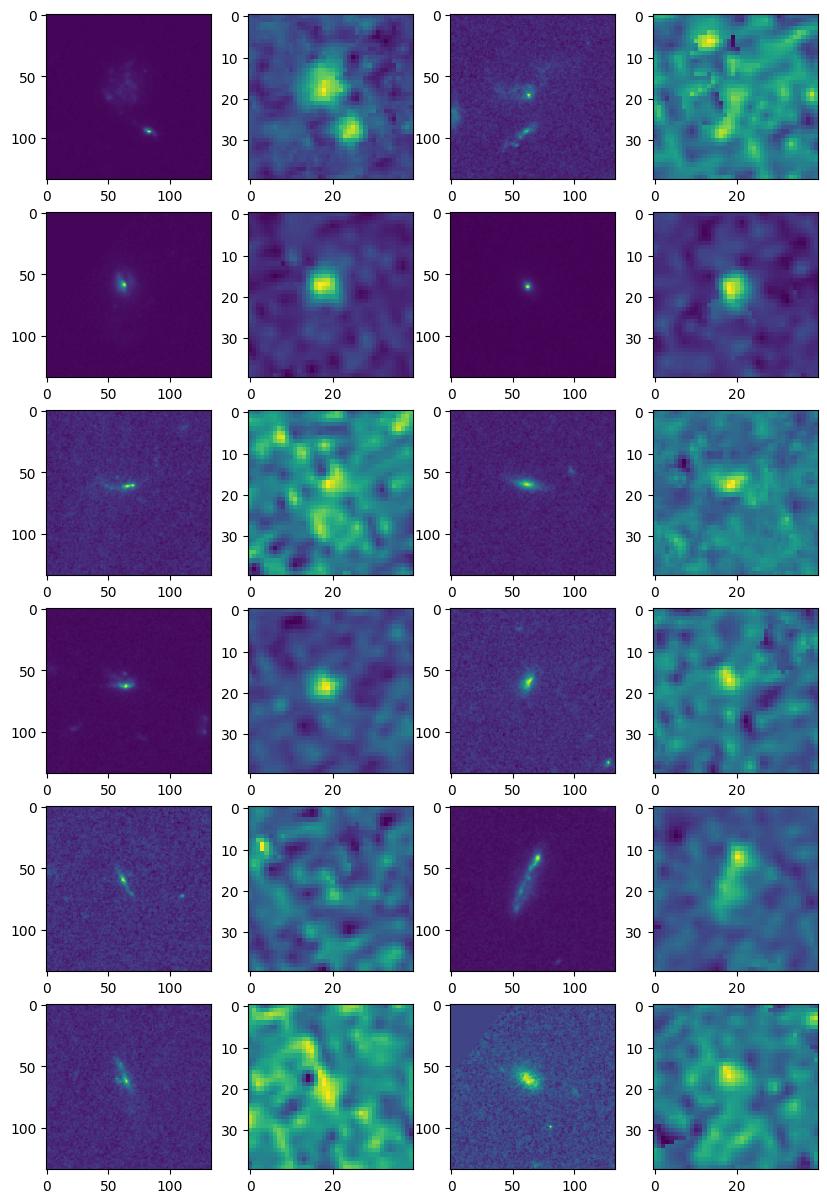

In [29]:
# Plotting images for verification purposes
n_rows = 6
fig, axes = plt.subplots(n_rows, 4, figsize=(10,2.5*n_rows))
for i in range(n_rows*2):
    clip_jwst = jwst_cutouts[i]
    clip_nisp = nisp_cutouts[i]
    axes.flatten()[i*2].imshow(clip_jwst)
    axes.flatten()[i*2+1].imshow(clip_nisp)
# plt.savefig("../plots/euclid_nisp_matches.png", bbox_inches='tight')

In [ ]:
# Some older reference info:
# test_nisp, test_jwst = clips[0][2], clips[0][1]
# N1, N2 = test_nisp.shape # Data is in Y, X format, so Y axis is 12455 and X axis is 9600
# # Corners for input into pixel_to_world are in X, Y format! (0,0), (9600,0), (0,12455), and (9600,12455)
# corners = np.array([[N1, 0],[0, 0], [0, N2], [N1, N2], [N1, 0]])
# corners_sky = test_nisp.wcs.pixel_to_world(corners[:,1], corners[:,0])
# corners_jwst = test_jwst.wcs.world_to_pixel(corners_sky)
# corners_jwst

In [ ]:
# plt.imshow(test_jwst.data)
# plt.plot(corners_jwst[0], corners_jwst[1], 'r-')
# plt.savefig("../plots/jwst_F115W_vs_nisp_mer_Yband.png", bbox_inches='tight')

In [25]:
# Convert one arcsecond to pixels
test_clip = clips[0][2]
start = test_clip.wcs.pixel_to_world(0,0)
sep = 1*u.arcsecond
end = start.directional_offset_by(0*u.arcsecond, sep)
x0, x1 = test_clip.wcs.world_to_pixel(start), test_clip.wcs.world_to_pixel(end)
x0, x1 = np.array(x0).flatten(), np.array(x1).flatten()
hyp = x0+x1
f"Clip pixel scale: {1/np.sqrt(np.dot(hyp, hyp))} as/px" # = as/px

'Clip pixel scale: 0.09999972422598206 as/px'

In [27]:
jwst_scale = 0.029994583232376477
nisp_scale = 0.09999972422598206
nisp_scale / jwst_scale

3.333926110966639

In [ ]:
# test_jwst.wcs, rotate_wcs(test_jwst).wcs.pc

In [ ]:
# -------------------------------------------------

In [28]:
jwst_cat_file = '../catalog/hlsp_jades_jwst_nircam_goods-s-deep_photometry_v2.0_catalog.fits'
candels_cat_file = '../catalog/gds.fits'
other_candels_cat_file = '../catalog/hlsp_candels_hst_wfc3_goodss-tot-multiband_f160w_v1_cat.fits'
matched_cat_file2 = '../catalog/matched_cat_HUDF.csv'
jwst_files = glob.glob("../data/hlsp_*")
nisp_files = glob.glob("../data/NISP_HUDF/*")

np_jwst_file2 = '../data/jwst_jades_66px.npy'
np_nisp_file2 = '../data/nisp_hudf_40px.npy'

In [29]:
# ## Uncomment this block to re-download the data
# search_radius = 5.5 * np.sqrt(2) * u.arcmin # Field is 11 square arcmin
# coord = SkyCoord.from_name('HUDF')
# print(coord)

# # IRSA table (HUDF field)
# image_tab = Irsa.query_sia(pos=(coord, search_radius), collection='euclid_DpdMerBksMosaic')
# nisp_tab=image_tab.to_pandas()
# nisp_tab=nisp_tab[ (nisp_tab['dataproduct_subtype']=='science') & 
#                         (nisp_tab['instrument_name']=='NISP') &
#                         (nisp_tab['energy_bandpassname']=='Y')].reset_index(drop=True)
# nisp_links = nisp_tab.access_url.to_list()

# # IRSA download
# for link in nisp_links:
#     fname = download_file(link)
#     with fits.open(fname) as hdul:
#         hdul.writeto(f'../data/NISP_HUDF/{link.split("/")[-1]}', overwrite=True)

# # JWST table (JADES field)
# f115w_obs = Observations.query_criteria(provenance_name="jades",instrument_name='NIRCAM/IMAGE', filters='F115W')
# data_products = Observations.get_product_list(f115w_obs)

# # JWST download
# Observations.download_products(data_products, download_dir='../data/JWST_JADES', flat=True)

/home/eaev/.local/lib/python3.9/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


6011

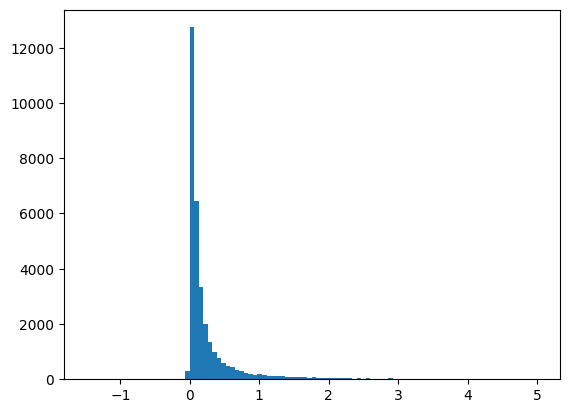

In [30]:
# cat_data_flag = Table.read(jwst_cat_file, hdu=2).to_pandas()
# cat_data_phot = Table.read(jwst_cat_file, hdu=4).to_pandas()
# cat_data_photoz = Table.read(jwst_cat_file, hdu=9).to_pandas()
# # FLAG_ST in hdu2 - star=1, gal=0
# # FLAG_BS (bright star) = 0
# # Ext 3 has size info (fwhm and such)
# # Ext 9 has photometric redshifts

# cat_data = Table.read(candels_cat_file, hdu=1).to_pandas()
# cat_data['ACS_F814W_MAG'] = 23.9-2.5*np.log10(cat_data.ACS_F814W_FLUX)
# cat_data = cat_data[
#         (cat_data.FLAGS==0)
#         & (cat_data.ACS_F814W_MAG < 25) # uJy conversion to M_AB
#         & (cat_data.FLUX_RADIUS_2_F814W < 24) # TODO: make sure this still applies, not sure if same instr./filt.
#         & (cat_data.CLASS_STAR < 0.05) # TODO: check this is what we want
# ].reset_index(drop=True)

cat_data = Table.read(candels_cat_file).to_pandas()
plt.hist(cat_data.ACS_F814W_FLUX[np.where((cat_data.ACS_F814W_FLUX<5)&(cat_data.ACS_F814W_FLUX>-20))[0]], bins=100)
cat_data['ACS_F814W_MAG'] = 23.9-2.5*np.log10(cat_data.ACS_F814W_FLUX)
cat_data = cat_data[
        (cat_data.z_best > 0.01) & (cat_data.z_best < 3.0)
        & (cat_data.ACS_F814W_MAG < 25)
        & (cat_data.FLUX_RADIUS_2_F814W < 50) & (cat_data.FLUX_RADIUS_2_F814W > 3) # Can be flexible with this (remove or make much larger)
        & (cat_data.CLASS_STAR < 0.1)
]
len(cat_data)

In [31]:
# # Merge JWST data tables on ID
# cat_data = pd.merge(cat_data_flag, cat_data_phot, on='ID', suffixes=(None, '_phot'))
# cat_data = pd.merge(cat_data, cat_data_photoz, on='ID', suffixes=(None, '_photoz'))
# # CUts
# cat_data = cat_data[
#         (cat_data.FLAG_ST!=1) # Why is every other value 32,768??? README said it would be 0???
#         # & (cat_data.F115W_CIRC0 ? need to calc flux->mag) # maybe R band instead
# ].reset_index(drop=True)

candels_cat = pd.DataFrame({
    'id': cat_data['ID'],
    'ra': cat_data['RA_1'],
    'dec': cat_data['DEC_1'],
    'jwst_image': '',
    'nisp_image': '',
})
candels_cat = candels_cat.dropna().reset_index(drop=True)

In [32]:
gal_coords = SkyCoord(candels_cat.ra, candels_cat.dec, unit='deg')

In [21]:
found_idxs = match_catalog(jwst_files[0], gal_coords, hdu_idx=1)
candels_cat.loc[found_idxs, 'jwst_image'] = str(jwst_files[0])

for file in nisp_files: # Only the third file actually matches anything
    found_idxs = match_catalog(file, gal_coords, hdu_idx=0)
    candels_cat.loc[found_idxs, 'nisp_image'] = str(file)

my_cat2 = candels_cat[candels_cat.nisp_image!='']
my_cat2 = my_cat2[my_cat2.jwst_image!=''].reset_index(drop=True)
# my_cat2.to_csv(matched_cat_file2, index=False)
my_cat2

,id,ra,dec,jwst_image,nisp_image
0,129,53.078146,-27.944680,../data/hlsp_jades_jwst_nircam_goods-s-deep_f1...,../data/NISP_HUDF/EUC_MER_BGSUB-MOSAIC-NIR-Y_T...
1,130,53.141210,-27.944984,../data/hlsp_jades_jwst_nircam_goods-s-deep_f1...,../data/NISP_HUDF/EUC_MER_BGSUB-MOSAIC-NIR-Y_T...
2,131,53.126114,-27.944847,../data/hlsp_jades_jwst_nircam_goods-s-deep_f1...,../data/NISP_HUDF/EUC_MER_BGSUB-MOSAIC-NIR-Y_T...
3,138,53.142817,-27.943848,../data/hlsp_jades_jwst_nircam_goods-s-deep_f1...,../data/NISP_HUDF/EUC_MER_BGSUB-MOSAIC-NIR-Y_T...
4,143,53.079345,-27.944364,../data/hlsp_jades_jwst_nircam_goods-s-deep_f1...,../data/NISP_HUDF/EUC_MER_BGSUB-MOSAIC-NIR-Y_T...
...,...,...,...,...,...
5006,24617,53.043272,-27.716899,../data/hlsp_jades_jwst_nircam_goods-s-deep_f1...,../data/NISP_HUDF/EUC_MER_BGSUB-MOSAIC-NIR-Y_T...
5007,24620,53.133854,-27.716544,../data/hlsp_jades_jwst_nircam_goods-s-deep_f1...,../data/NISP_HUDF/EUC_MER_BGSUB-MOSAIC-NIR-Y_T...
5008,24668,53.011294,-27.719674,../data/hlsp_jades_jwst_nircam_goods-s-deep_f1...,../data/NISP_HUDF/EUC_MER_BGSUB-MOSAIC-NIR-Y_T...
5009,24669,53.169494,-27.721165,../data/hlsp_jades_jwst_nircam_goods-s-deep_f1...,../data/NISP_HUDF/EUC_MER_BGSUB-MOSAIC-NIR-Y_T...


In [22]:
clips = clip_images(my_cat2, pad=0, rot_jwst=0)
len(clips)

2099

In [ ]:
# Arrange data
jwst_cutouts = np.array([clip[1].data for clip in clips])
nisp_cutouts = np.array([clip[2].data for clip in clips])

# Save files
np.save(np_jwst_file2, jwst_cutouts, allow_pickle=False)
np.save(np_nisp_file2, nisp_cutouts, allow_pickle=False)

In [24]:
# idx=5
# test_jwst_file, test_nisp_file = my_cat2.iloc[idx].jwst_image, my_cat2.iloc[idx].nisp_image
# coord = SkyCoord(my_cat2.iloc[idx].ra, my_cat2.iloc[idx].dec, unit='deg')
# print(coord)
# with fits.open(test_jwst_file) as hdul:
#     hdul.info()

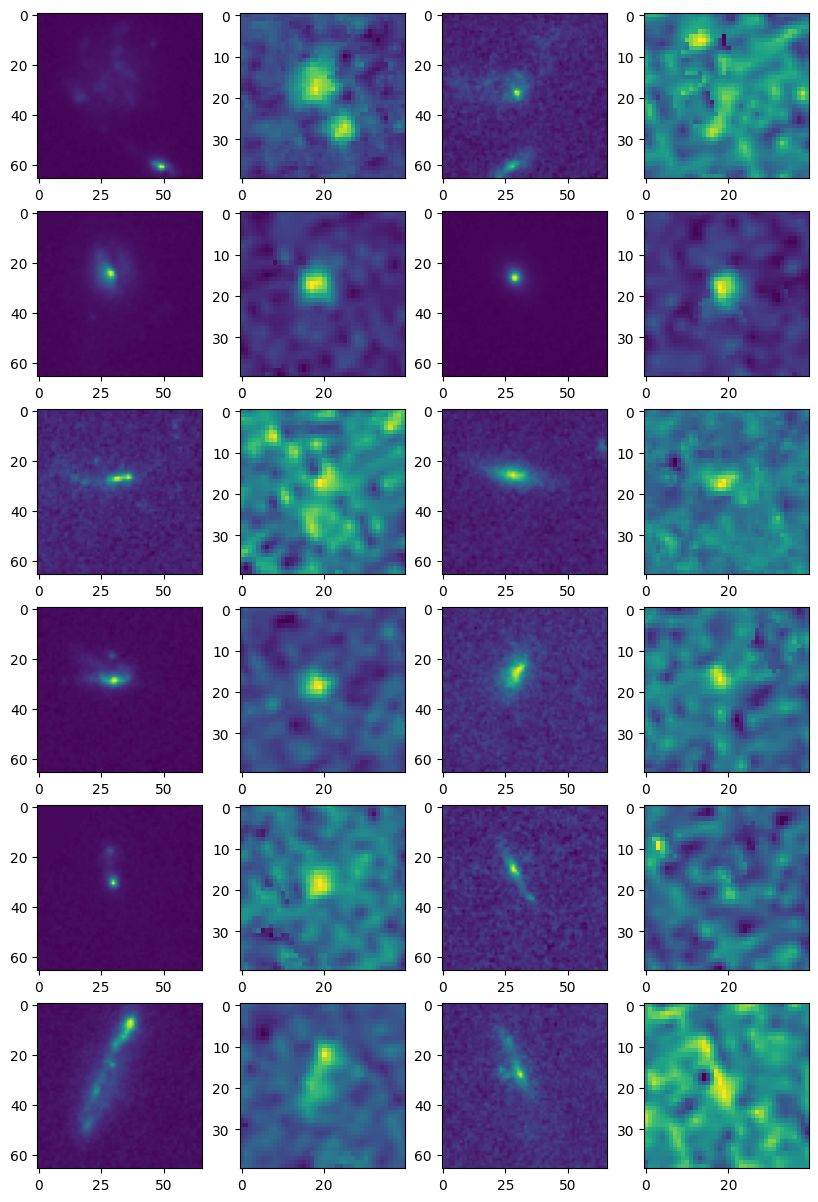

In [25]:
# Plotting images for verification purposes
n_rows = 6
fig, axes = plt.subplots(n_rows, 4, figsize=(10,2.5*n_rows))
for i in range(n_rows*2):
    clip_jwst = jwst_cutouts[i]
    clip_nisp = nisp_cutouts[i]
    axes.flatten()[i*2].imshow(clip_jwst)
    axes.flatten()[i*2+1].imshow(clip_nisp)
# plt.savefig("../plots/euclid_nisp_matches.png", bbox_inches='tight')
# These look kinda bad... WCS may be inaccurate? Rotation different? No flux filter?
# Also getting a lot of correlated noise on the Euclid images. Am I rotating those by mistake?
# Second try: There is just nothing in the JWST images?
# Many... tries... later: I managed to filter out the nothing JWST images and get the WCS right.
# Seems like the JWST images have an offset, consult the paper Shooby sent to find out more

In [26]:
# Lots of correlated noise in the Euclid images still
# Seems to be a worse-quality match than those from the COSMOS field

# Adding in PSFs

In [47]:
import photutils as phot
import galsim
nisp_psffile_1 = "../data/psf_image_Inflight_dither_6.fits"
nisp_psffile_2 = "../data/psf_image_Inflight_dither_69.fits"
psf_files = glob.glob("../data/PSFs/*.fits")

In [48]:
for i in range(len(psf_files)):
    print(f'{i}: {psf_files[i].split("/")[-1]}')

0: psf_image_Inflight_dither_6.fits
1: psf_v.fits
2: psf_b.fits
3: psf_gsd_f814w_full_60mas.fits
4: psf_i.fits
5: psf_image_Inflight_dither_69.fits
6: psf_z.fits
7: psf_h.fits
8: psf_j.fits
9: psf_y.fits
10: psf-calexp-pdr3_dud-HSC-I-9813-5,5-150.12000-2.33500.fits


In [59]:
with fits.open(psf_files[3]) as hdul:
    print(hdul.info())

Filename: ../data/PSFs/psf_gsd_f814w_full_60mas.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     503   (168, 168)   float32   
None


(167, 167)

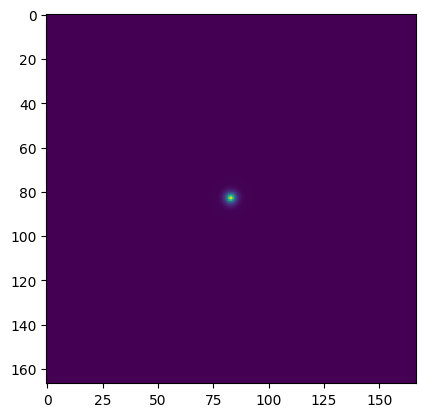

In [63]:
with fits.open(psf_files[8]) as hdul:
    test_img = hdul[0].data
plt.imshow(test_img)
test_img.shape

In [ ]:
psfs = {}
with fits.open(nisp_psffile_1) as hdul:
    for hdu in hdul:
        if hdu.data is not None:
            det_id = hdu.header['DET_ID'].strip()
            psfs[det_id] = hdu.data
test_psf = psfs['11']

In [ ]:
real_image = galsim.ImageF(40,40)
real_image.array = test_img
real_psf = galsim.ImageF(test_psf.shape[0], test_psf.shape[1])
real_psf.array = test_psf
galsim.hsm.EstimateShear(real_image, real_psf), '\n', real_image.FindAdaptiveMom()

In [ ]:
gal = galsim.Gaussian(flux=1e-5, sigma=1)
gal2_on = True
e1, e2 = 0.1, 0.2
gal = gal.shear(e1=e1, e2=e2)
gal2 = galsim.Gaussian(flux=5e-5, sigma=1)
gal2 = gal2.shift(dx=5, dy=5)
gals = gal + gal2 if gal2_on else gal
fake_psf = galsim.Gaussian(sigma=.1)
final = galsim.Convolve([gals, fake_psf])
print(galsim.hsm.EstimateShear(final.drawImage(scale=.1), fake_psf.drawImage(scale=.1)))
final_img = final.drawImage(scale=.1)
plt.imshow(final_img.array)

In [ ]:
fake_real_img = galsim.ImageF(*final_img.array.shape)
fake_real_img.array = final_img.array
galsim.hsm.EstimateShear(fake_real_img, fake_psf.drawImage(scale=0.1))

# Starting on the SR GAN

In [ ]:
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import time
import random

In [ ]:
jwst_file = "../data/jwst_data_66px.npy"
nisp_file = "../data/nisp_data_40px.npy"

In [ ]:
tfms = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])

def transform_data(img_data, tiny=1e-8):
    # Flattens higher values
    img_data = np.arcsinh(img_data)
    
    # Normalize to [0,1]
    img_data = (img_data - img_data.min()) / (img_data.max() - img_data.min() + tiny)
    # Can this normalization be reversed without knowing what the max / min values were?
    
    # Transform
    return tfms(img_data.astype(np.float32))  # Convert properly

In [ ]:
np.random.seed(42)
class SuperResolutionDataset(Dataset):
    def __init__(self, lr_path, hr_path=None, transform=None, inference_mode=False, 
                 split='train', sample_fraction=1.0):
        """
        Dataset that loads LR images and optionally HR images.

        :param lr_hdf5_path: Path to Low-Resolution numpy file
        :param hr_hdf5_path: Path to High-Resolution numpy file (optional)
        :param transform: Optional torchvision transforms
        :param inference_mode: If True, returns only LR images (for super-res inference)
        """
        self.lr_path = lr_path
        self.hr_path = hr_path  # Can be None
        self.transform = transform
        self.split = split
        self.inference_mode = inference_mode  # If True, load only LR

        # Load keys from LR file
        self.lr_data = np.load(self.lr_path, mmap_mode='r')
        # Using self.keys as indices
        self.keys = np.arange(self.lr_data.shape[0])
        
        # TODO: Ask Shooby what percentage she wants in train/test split
        if self.split=='train': # Take 80%
            N = int(len(self.keys) * 0.8)
            self.keys = np.random.choice(self.keys, N, replace=False)
        else: # Take 20%
            N = int(len(self.keys)*0.2)
            self.keys = np.random.choice(self.keys, N, replace=False)
        
        # Subsample the dataset
        if sample_fraction < 1.0:
            num_samples = int(len(self.keys) * sample_fraction)
            self.keys = np.random.choice(self.keys, num_samples, replace=False)
        
        self.lr_data = self.lr_data[self.keys]

        # Check if HR exists
        self.has_hr = hr_path is not None
        if self.has_hr:
            self.hr_data = np.load(self.hr_path, mmap_mode='r')
            self.hr_data = self.hr_data[self.keys]
    
    def __len__(self):
        return len(self.lr_data)

    def __getitem__(self, idx):

        # Read one part of numpy array
        lr_image = transform_data(self.lr_data[idx])

        # Convert to tensor
        lr_image = torch.tensor(lr_image, dtype=torch.float32)

        # If in inference mode OR no HR data, return only LR image
        if self.inference_mode or not self.has_hr:
            return lr_image

        # Load HR image only if available
        hr_image = transform_data(self.hr_data[idx])
        hr_image = torch.tensor(hr_image, dtype=torch.float32)
        return lr_image, hr_image  # Training case (LR, HR)

In [ ]:
# Load Training Dataset (for checking shape)
train_dataset = SuperResolutionDataset(nisp_file, jwst_file, split="train")
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

# Get a batch for training
lr_batch, hr_batch = next(iter(train_loader))
print("Training Mode:")
print("LR Batch Shape:", lr_batch.shape)  # Expected: (16, 1, 40, 40)
print("HR Batch Shape:", hr_batch.shape)  # Expected: (16, 1, 66, 66)

# Load Test Dataset (for evaluation)
test_dataset = SuperResolutionDataset(nisp_file, jwst_file, split="test")
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

# Get a batch for inference (only LR images)
lr_batch, hr_batch = next(iter(test_loader))
print("Inference Mode:")
print("LR Batch Shape:", lr_batch.shape)  # Expected: (16, 1, 40, 40)
print("HR Batch Shape:", hr_batch.shape)  # Expected: (16, 1, 66, 66)

In [ ]:
class SuperResDiffusionUNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, hidden_dim=64, activation_fn=nn.ReLU):
        super().__init__()

        self.activation_fn = activation_fn  # Store the class, not an instance

        # Encoder
        self.encoder1 = nn.Sequential(
            nn.Conv2d(in_channels, hidden_dim, kernel_size=4, stride=2, padding=1),
            self.activation_fn(),  # Instantiate it here
        )
        self.encoder2 = nn.Sequential(
            nn.Conv2d(hidden_dim, hidden_dim * 2, kernel_size=4, stride=2, padding=1),
            self.activation_fn(),
        )
        self.encoder3 = nn.Sequential(
            nn.Conv2d(hidden_dim * 2, hidden_dim * 4, kernel_size=4, stride=2, padding=1),
            self.activation_fn(),
        )

        # Condition Projection
        self.condition_proj = nn.Conv2d(1, hidden_dim * 4, kernel_size=3, padding=1)

        # Cross-Attention
        self.cross_attention = nn.Conv2d(hidden_dim * 4 * 2, hidden_dim * 4, kernel_size=1)

        # Decoder
        self.decoder1 = nn.Sequential(
            nn.ConvTranspose2d(hidden_dim * 4, hidden_dim * 2, kernel_size=4, stride=2, padding=1, output_padding=1),
            self.activation_fn(),
        )
        self.decoder2 = nn.Sequential(
            nn.ConvTranspose2d(hidden_dim * 2, hidden_dim, kernel_size=4, stride=2, padding=1, output_padding=1),
            self.activation_fn(),
        )
        self.decoder3 = nn.Conv2d(hidden_dim, out_channels, kernel_size=3, padding=1)

    def forward(self, x, condition):
        x1 = self.encoder1(x)
        x2 = self.encoder2(x1)
        x3 = self.encoder3(x2)

        condition = self.condition_proj(condition)
        condition = F.interpolate(condition, size=(x3.shape[2], x3.shape[3]), mode="bilinear", align_corners=True)

        x3 = torch.cat([x3, condition], dim=1)
        x3 = self.cross_attention(x3)

        x = self.decoder1(x3)
        x = self.align_dims(x, x2)  # Alignment before adding
        x = x + x2  # Skip connection

        x = self.decoder2(x)
        x = self.align_dims(x, x1)  # Alignment before adding
        x = x + x1  # Skip connection

        x = self.decoder3(x)
        return x

    def align_dims(self, x, target):
        if x.size() != target.size():
            diffY = target.size(2) - x.size(2)
            diffX = target.size(3) - x.size(3)
            x = F.pad(x, [diffX // 2, diffX - diffX // 2,
                          diffY // 2, diffY - diffY // 2])
        return x


# Upsampler that ensures output is exactly 66×66
class Upsampler(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, upscale_factor=2):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, in_channels * (upscale_factor ** 2), kernel_size=3, padding=1)
        self.pixel_shuffle = nn.PixelShuffle(upscale_factor)
        self.relu = nn.ReLU()
        self.conv2 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)

    def forward(self, x):
        x = x.to(next(self.parameters()).device)
        x = self.relu(self.pixel_shuffle(self.conv1(x)))
        x = self.conv2(x)
        return x


# Diffusion Model with Cosine Noise Schedule
def cosine_schedule(t, total_timesteps=500):
    return torch.cos((t / total_timesteps) * (0.5 * torch.pi))


class DiffusionModel(nn.Module):
    def __init__(self, unet_model, timesteps=500):
        super().__init__()
        self.unet = unet_model
        self.timesteps = timesteps

    def forward(self, x, t, condition):
        x = x.to(next(self.parameters()).device)
        t = t.to(next(self.parameters()).device)
        condition = condition.to(next(self.parameters()).device)
        return self.unet(x, condition)


# Full Super-Resolution Diffusion Model
class SuperResolutionDiffusion(nn.Module):
    def __init__(self, unet_model, upsampler):
        super().__init__()
        self.upsampler = upsampler
        self.diffusion = DiffusionModel(unet_model)

    def forward(self, x, t):
        x = x.to(next(self.parameters()).device)
        t = t.to(next(self.parameters()).device)

        upscaled = self.upsampler(x)

        # Add progressive noise with cosine schedule
        noise = torch.randn_like(upscaled, device=upscaled.device)
        alpha_t = cosine_schedule(t, self.diffusion.timesteps).view(-1, 1, 1, 1)
        noisy_image = alpha_t * upscaled + (1 - alpha_t) * noise

        output = self.diffusion(noisy_image, t, upscaled)

        # Final size correction
        return nn.functional.interpolate(output, size=(66, 66), mode="bilinear", align_corners=True)

# Instantiate models and move them to GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
unet = SuperResDiffusionUNet(in_channels=1, out_channels=1).to(device)
upsampler = Upsampler().to(device)
model = SuperResolutionDiffusion(unet, upsampler).to(device)

# Example input on GPU
x = torch.randn(1, 1, 40, 40, device=device) 
t = torch.tensor([500], device=device) 

# Run the model
output = model(x, t)

print("Output shape:", output.shape) 

In [ ]:
# Load Training Dataset (set split="train" explicitly)
train_dataset = SuperResolutionDataset(nisp_file, jwst_file, split="train")
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

# Fetch a batch from the training dataset
lr_batch, hr_batch = next(iter(train_loader))

# Convert tensors to NumPy for visualization
lr_batch_np = lr_batch.squeeze().cpu().numpy()  
hr_batch_np = hr_batch.squeeze().cpu().numpy()  

# Plot first 4 samples
fig, axes = plt.subplots(4, 2, figsize=(6, 8))

for i in range(4):
    # Low-Res Image
    img1 = axes[i, 0].imshow(lr_batch_np[i], cmap='gray')
    axes[i, 0].set_title(f"Low-Res {i}")
    axes[i, 0].axis("off")
    fig.colorbar(img1, ax=axes[i, 0], fraction=0.046, pad=0.04)  # Add colorbar

    # High-Res Image
    img2 = axes[i, 1].imshow(hr_batch_np[i], cmap='gray')
    axes[i, 1].set_title(f"High-Res {i}")
    axes[i, 1].axis("off")
    fig.colorbar(img2, ax=axes[i, 1], fraction=0.046, pad=0.04)  # Add colorbar

plt.tight_layout()
plt.show()

In [ ]:
# Use Mean Squared Error (MSE) Loss for Super-Resolution
criterion = nn.MSELoss()

# Define optimizer
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)

# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Number of epochs
num_epochs = 50

# Train-Test Dataloaders
train_loader = DataLoader(
    SuperResolutionDataset(nisp_file, jwst_file, split="train", sample_fraction=0.1),
    batch_size=128, shuffle=True, num_workers=8, pin_memory=True, persistent_workers=True
)

test_loader = DataLoader(
    SuperResolutionDataset(nisp_file, jwst_file, split="test"),
    batch_size=128, shuffle=False, num_workers=8, pin_memory=True, persistent_workers=True
)

# Training loop
for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    start_time = time.time()

    print(f"Starting Epoch {epoch+1}...") 

    for batch_idx, (lr_batch, hr_batch) in enumerate(train_loader):

        lr_batch, hr_batch = lr_batch.to(device), hr_batch.to(device)
        t = torch.randint(0, model.diffusion.timesteps, (lr_batch.shape[0],), device=device)
        
        output = model(lr_batch, t)# Forward pass
        loss = criterion(output, hr_batch)# Compute loss
        epoch_loss += loss.item()
        
        optimizer.zero_grad()# Backpropagation
        loss.backward()
        optimizer.step()

    avg_loss = epoch_loss / len(train_loader)
    elapsed_time = time.time() - start_time

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.6f}, Time: {elapsed_time:.2f}s")

# Save trained model
torch.save(model.state_dict(), "super_resolution_model.pth")
print("Model saved successfully!")

# Evaluate (Shooby's code)

In [ ]:
import torch
import wandb
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
import random

# Load model
checkpoint_path = "super_resolution_model.pth"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

unet = SuperResDiffusionUNet(in_channels=1, out_channels=1).to(device)
upsampler = Upsampler().to(device)
model = SuperResolutionDiffusion(unet, upsampler).to(device)

model.load_state_dict(torch.load(checkpoint_path, map_location=device))
model.eval()

# Define DataLoader with num_workers for speed
test_loader = DataLoader(
    SuperResolutionDataset(nisp_file, jwst_file, split="test"),
    batch_size=16,  # Best balance
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    prefetch_factor=4,
    persistent_workers=True
)

In [ ]:
# Select a random batch **without loading all**
random_batch_idx = random.randint(0, len(test_loader) - 1)
for i, (lr_batch, hr_batch) in enumerate(test_loader):
    if i == random_batch_idx:
        break

lr_batch, hr_batch = lr_batch.to(device), hr_batch.to(device)

# Generate super-resolution images using AMP (faster)
with torch.no_grad(), torch.cuda.amp.autocast():
    t_test = torch.zeros((lr_batch.shape[0],), dtype=torch.long, device=device)  # t=0 for final reconstruction
    sr_batch = model(lr_batch, t_test).cpu()  # Move back to CPU

# Convert tensors to NumPy for visualization
lr_batch_np = lr_batch.cpu().squeeze().numpy()  
sr_batch_np = sr_batch.cpu().squeeze().numpy()  
hr_batch_np = hr_batch.cpu().squeeze().numpy()  

# Plot results
num_images = min(4, lr_batch.shape[0])
fig, axes = plt.subplots(num_images, 3, figsize=(10, 12))

for i in range(num_images):
    # Low-Resolution Image
    img1 = axes[i, 0].imshow(lr_batch_np[i], cmap='gray')
    axes[i, 0].set_title(f"Low-Res {i}")
    axes[i, 0].axis("off")
    fig.colorbar(img1, ax=axes[i, 0], fraction=0.046, pad=0.04)

    # Super-Resolved Image
    img2 = axes[i, 1].imshow(sr_batch_np[i], cmap='gray')
    axes[i, 1].set_title(f"Super-Res {i}")
    axes[i, 1].axis("off")
    fig.colorbar(img2, ax=axes[i, 1], fraction=0.046, pad=0.04)

    # High-Resolution Image (Ground Truth)
    img3 = axes[i, 2].imshow(hr_batch_np[i], cmap='gray')
    axes[i, 2].set_title(f"High-Res {i}")
    axes[i, 2].axis("off")
    fig.colorbar(img3, ax=axes[i, 2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

In [ ]:
import time

for batch_size in [4, 8, 16, 32, 64]:  # Try different batch sizes
    test_loader = DataLoader(
        SuperResolutionDataset(nisp_file, jwst_file, split="test"),
        batch_size=batch_size,
        shuffle=False,
        num_workers=2,
        pin_memory=True,
        prefetch_factor=4,
        persistent_workers=True
    )

    start = time.time()
    lr_batch, hr_batch = next(iter(test_loader))
    end = time.time()

    print(f"Batch size {batch_size}: Data loading time = {end - start:.3f} seconds")

# With W and B

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import time
import wandb
from torch.utils.data import DataLoader
import random

def normalize_image(img):
    img = img.squeeze().cpu().numpy()
    img_min, img_max = img.min(), img.max()
    if img_max > img_min:
        img = (img - img_min) / (img_max - img_min)
    return (img * 255).astype("uint8")
    
# Initialize Weights & Biases
wandb.init(
    project="super-resolution-diffusion",
    config={
        "epochs": 30,
        "learning_rate": 1e-4,
        "batch_size": 64,  # Increased for better GPU utilization
        "optimizer": "AdamW",
        "loss_function": "MSELoss"
    }
)

# Enable CuDNN Optimization
torch.backends.cudnn.benchmark = True  

# Define loss function & optimizer
criterion = nn.MSELoss()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Instantiate & Move Model to GPU
unet = SuperResDiffusionUNet(in_channels=1, out_channels=1).to(device)
upsampler = Upsampler().to(device)
model = SuperResolutionDiffusion(unet, upsampler).to(device)

# Define optimizer
optimizer = optim.AdamW(model.parameters(), lr=wandb.config["learning_rate"], weight_decay=1e-5)

# Optimized Training DataLoader (Restored `num_workers=8`)
train_loader = DataLoader(
    SuperResolutionDataset(nisp_file, jwst_file, split="train", sample_fraction=0.1),
    batch_size=wandb.config["batch_size"],
    shuffle=True,
    num_workers=8,  # ✅ Restored 8 workers for fast training
    pin_memory=True, 
    persistent_workers=True  # ✅ Keeps workers alive for speed
)

# Optimized Test DataLoader (Restored `persistent_workers=True`)
test_loader = DataLoader(
    SuperResolutionDataset(nisp_file, jwst_file, split="test", sample_fraction=0.1),
    batch_size=wandb.config["batch_size"],
    shuffle=False,
    num_workers=2,  # ✅ Test set is smaller, 2 workers is enough
    pin_memory=True, 
    persistent_workers=True  # ✅ Restored to prevent slow reloading
)

# Enable Mixed Precision Training
scaler = torch.amp.GradScaler(device='cuda')  

# Training loop
num_epochs = wandb.config["epochs"]
for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    start_time = time.time()

    for batch_idx, (lr_batch, hr_batch) in enumerate(train_loader):
        lr_batch, hr_batch = lr_batch.to(device, non_blocking=True), hr_batch.to(device, non_blocking=True)
        t = torch.randint(0, model.diffusion.timesteps, (lr_batch.shape[0],), device=device)

        optimizer.zero_grad()

        with torch.amp.autocast(device_type='cuda'):
            output = model(lr_batch, t)
            loss = criterion(output, hr_batch)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        torch.cuda.synchronize()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    elapsed_time = time.time() - start_time

    print(f"✅ Epoch {epoch + 1}/{num_epochs} completed in {elapsed_time:.2f} seconds. Loss: {avg_loss:.6f}")

    wandb.log({
        "epoch": epoch + 1,
        "train_loss": avg_loss,
        "time_per_epoch": elapsed_time,
        "gpu_usage": torch.cuda.memory_allocated(device) / 1e9,
        "gpu_max_allocated": torch.cuda.max_memory_allocated(device) / 1e9,
        "learning_rate": optimizer.param_groups[0]["lr"],
    })

    if (epoch + 1) % 5 == 0:
        model.eval()
        with torch.no_grad():
            # Select a random index from the dataset directly
            random_idx = random.randint(0, len(test_loader.dataset) - 1)    
            lr_img, hr_img = test_loader.dataset[random_idx]
            lr_img = lr_img.unsqueeze(0).to(device)  # Add batch dimension

            #Generate super-resolution image
            t_test = torch.zeros((1,), dtype=torch.long, device=device)
            sr_img = model(lr_img, t_test).cpu().squeeze(0)

            # Normalize images
            lr_img = normalize_image(lr_img)
            sr_img = normalize_image(sr_img)
            hr_img = normalize_image(hr_img)

            # Log to WandB
            wandb.log({
                "low_res": wandb.Image(lr_img, caption=f"Low-Res {random_idx}"),
                "super_res": wandb.Image(sr_img, caption=f"Super-Res {random_idx}"),
                "high_res": wandb.Image(hr_img, caption=f"High-Res {random_idx}"),
            })
        model.train()

In [ ]:
import torch
import wandb
import numpy as np
from torch.utils.data import DataLoader

# Initialize WandB
if wandb.run is None:
    wandb.init(project="super-resolution-diffusion-eval")

# Define device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load model
unet = SuperResDiffusionUNet(in_channels=1, out_channels=1).to(device)
upsampler = Upsampler().to(device)
model = SuperResolutionDiffusion(unet, upsampler).to(device)

checkpoint_path = "super_resolution_model.pth"
model.load_state_dict(torch.load(checkpoint_path, map_location=device))
model.eval()

# Define dataset and DataLoader
lr_hdf5_path = "../data/Nisp_train.hdf5"
hr_hdf5_path = "../data/Nircam_train.hdf5"
test_dataset = SuperResolutionDataset(nisp_file, jwst_file, split="test")
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=2)

# Fetch a test batch
lr_batch, hr_batch = next(iter(test_loader))
lr_batch, hr_batch = lr_batch.to(device), hr_batch.to(device)

# Generate super-resolution (SR) images
with torch.no_grad():
    t_test = torch.zeros((lr_batch.shape[0],), dtype=torch.long, device=device)  # Set t=0 for final reconstruction
    sr_batch = model(lr_batch, t_test)

# Move tensors to CPU & detach
lr_batch = lr_batch.cpu().detach().numpy()
sr_batch = sr_batch.cpu().detach().numpy()
hr_batch = hr_batch.cpu().detach().numpy()

# Ensure batch size does not exceed available images
num_samples = min(4, lr_batch.shape[0])

# Convert to valid image range [0, 255] & prevent NaNs
def normalize_image(img):
    img = np.nan_to_num(img)  # Replace NaNs with 0
    img = (img - np.min(img, axis=(0, 1), keepdims=True)) / (np.ptp(img, axis=(0, 1), keepdims=True) + 1e-8)
    return (img * 255).astype(np.uint8)

# Prepare images for WandB
table = wandb.Table(columns=["Low-Res", "Super-Res", "High-Res"])
for i in range(num_samples):
    lr_img = normalize_image(lr_batch[i].squeeze())
    sr_img = normalize_image(sr_batch[i].squeeze())
    hr_img = normalize_image(hr_batch[i].squeeze())

    table.add_data(wandb.Image(lr_img, caption=f"Low-Res {i}"),
                   wandb.Image(sr_img, caption=f"Super-Res {i}"),
                   wandb.Image(hr_img, caption=f"High-Res {i}"))

# Log results to WandB
wandb.log({"Super-Resolution Results": table})

wandb.finish()